## Домашнее задание к занятию "A/B-тесты"

### Описание задачи

![banner](https://storage.googleapis.com/kaggle-datasets-images/635/1204/126be74882028aac7241553cef0e27a7/dataset-original.jpg)

Покемоны - это маленькие существа, которые сражаются друг с другом на соревнованиях. Все покемоны имеют разные характеристики (сила атаки, защиты и т. д.) И относятся к одному или двум так называемым классам (вода, огонь и т. д.).
Профессор Оук является изобретателем Pokedex - портативного устройства, которое хранит информацию обо всех существующих покемонах. Как его ведущий специалист по данным, Вы только что получили от него запрос с просьбой осуществить аналитику данных на всех устройствах Pokedex.

### Описание набора данных
Профессор Оук скопировал все содержимое в память одного устройства Pokedex, в результате чего получился набор данных, с которым Вы будете работать в этой задаче. В этом файле каждая строка представляет характеристики одного покемона:

* `pid`: Numeric - ID покемона
* `HP`: Numeric - Очки здоровья
* `Attack`: Numeric - Сила обычной атаки
* `Defense`: Numeric - Сила обычной защиты
* `Sp. Atk`: Numeric - Сила специальной атаки
* `Sp. Def`: Numeric - Сила специальной защиты
* `Speed`: Numeric - Скорость движений
* `Legendary`: Boolean - «True», если покемон редкий
* `Class 1`: Categorical - Класс покемона
* `Class 2`: Categorical - Класс покемона

In [331]:
import warnings
# Отключение предупреждений (warnings)
warnings.filterwarnings("ignore")

import pandas as pd
import scipy.stats as st
from scipy.stats import ttest_ind
from scipy.stats import f_oneway, shapiro
import seaborn as sns

import matplotlib.pyplot as plt

pokemon = pd.read_csv('https://raw.githubusercontent.com/a-milenkin/datasets_for_t-tests/main/pokemon.csv', on_bad_lines='skip')  # Откроем датасет
pokemon.head()
pokemon.info()
pokemon.head()
# Обратите внимание, что у покемона может быть один или два класса.
# Если у покемона два класса, считается, что они имеют одинаковую значимость.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   pid        800 non-null    int64 
 1   Name       799 non-null    object
 2   Class 1    800 non-null    object
 3   Class 2    414 non-null    object
 4   HP         800 non-null    int64 
 5   Attack     800 non-null    int64 
 6   Defense    800 non-null    int64 
 7   Sp. Atk    800 non-null    int64 
 8   Sp. Def    800 non-null    int64 
 9   Speed      800 non-null    int64 
 10  Legendary  800 non-null    bool  
dtypes: bool(1), int64(7), object(3)
memory usage: 63.4+ KB


,pid,Name,Class 1,Class 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Legendary
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,False
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,False
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,False
3,4,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,False
4,5,Charmander,Fire,NaN,39,52,43,60,50,65,False


In [339]:
"""Удаление пропусков в столбце name"""
pokemon = pokemon.dropna(subset=['Name']).reset_index(drop=True)
pokemon.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 799 entries, 0 to 798
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   pid        799 non-null    int64 
 1   Name       799 non-null    object
 2   Class 1    799 non-null    object
 3   Class 2    414 non-null    object
 4   HP         799 non-null    int64 
 5   Attack     799 non-null    int64 
 6   Defense    799 non-null    int64 
 7   Sp. Atk    799 non-null    int64 
 8   Sp. Def    799 non-null    int64 
 9   Speed      799 non-null    int64 
 10  Legendary  799 non-null    bool  
dtypes: bool(1), int64(7), object(3)
memory usage: 63.3+ KB


### Задачи

<div class="alert alert-info">
<b>Задание № 1:</b>
    
Профессор Оук подозревает, что покемоны в классе `Grass` имеют более сильную обычную атаку, чем покемоны в классе `Rock`. Проверьте, прав ли он, и убедите его в своём выводе статистически.
    
    
Примечание: если есть покемоны, которые относятся к обоим классам, просто выбросьте их;
    
Вы можете предположить, что распределение обычных атак является нормальным для всех классов покемонов.

</div>

In [294]:
"""Выброс покемонов, которые относятся к двум этим классам одновременно"""

pokemon_new = pokemon.loc[~(((pokemon['Class 1'] == 'Grass') | (pokemon['Class 2'] == 'Grass')) & ((pokemon['Class 1'] == 'Rock') | (pokemon['Class 2'] == 'Rock')))]

pokemon_new.info()
pokemon_new.head()




<class 'pandas.core.frame.DataFrame'>
Index: 797 entries, 0 to 796
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   pid        797 non-null    int64 
 1   Name       797 non-null    object
 2   Class 1    797 non-null    object
 3   Class 2    412 non-null    object
 4   HP         797 non-null    int64 
 5   Attack     797 non-null    int64 
 6   Defense    797 non-null    int64 
 7   Sp. Atk    797 non-null    int64 
 8   Sp. Def    797 non-null    int64 
 9   Speed      797 non-null    int64 
 10  Legendary  797 non-null    bool  
dtypes: bool(1), int64(7), object(3)
memory usage: 69.3+ KB


,pid,Name,Class 1,Class 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Legendary
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,False
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,False
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,False
3,4,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,False
4,5,Charmander,Fire,NaN,39,52,43,60,50,65,False


Подсчет показателей для двух групп

In [432]:
pokemon_new.loc[(pokemon_new['Class 1'] =='Grass') | (pokemon_new['Class 2'] =='Grass')]['Attack'].describe()

count     93.000000
mean      73.731183
std       24.179645
min       27.000000
25%       59.000000
50%       70.000000
75%       95.000000
max      132.000000
Name: Attack, dtype: float64

In [433]:
pokemon_new.loc[(pokemon_new['Class 1'] =='Rock') | (pokemon_new['Class 2'] =='Rock')]['Attack'].describe()

count     56.000000
mean      91.785714
std       34.805284
min       10.000000
25%       63.000000
50%       92.500000
75%      116.250000
max      165.000000
Name: Attack, dtype: float64

stat = 0.978, p = 0.11250
Вероятно нормальное распределение


<Axes: ylabel='Density'>

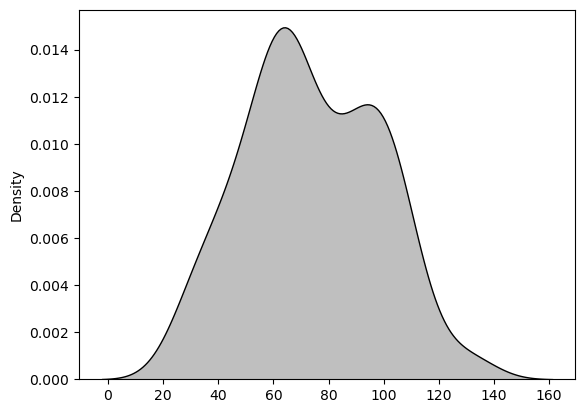

In [434]:
"""Проверка нормальности распределения"""
data_grass = pokemon_new.loc[(pokemon_new['Class 1'] =='Grass') | (pokemon_new['Class 2'] =='Grass')]['Attack'].values

stat, p = st.shapiro(data_grass)
print(f'stat = {stat:.3f}, p = {p:.5f}')

if p > 0.05:
	print('Вероятно нормальное распределение')
else:
	print('Вероятно не нормальное распределение')
	
sns.kdeplot(data_grass, label="Control", fill = True, color = '#000000')

stat = 0.982, p = 0.58551
Вероятно нормальное распределение


<Axes: ylabel='Density'>

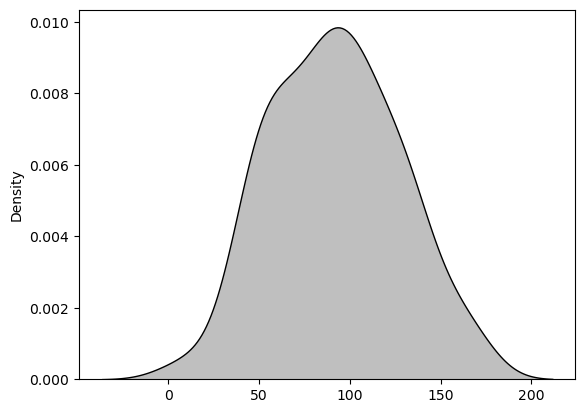

In [435]:
"""Проверка нормальности распределения"""
data_rock = pokemon_new.loc[(pokemon_new['Class 1'] =='Rock') | (pokemon_new['Class 2'] =='Rock')]['Attack'].values

stat, p = st.shapiro(data_rock)
print(f'stat = {stat:.3f}, p = {p:.5f}')

if p > 0.05:
	print('Вероятно нормальное распределение')
else:
	print('Вероятно не нормальное распределение')
	
sns.kdeplot(data_rock, label="Control", fill = True, color = '#000000')

Исходя из условия задачи, считаем, что данные распределены нормальны, и тест показал такие же результаты

In [436]:

"""Проверка нулевой гипотезы - разница в обычной атаке незначительна"""
stat, p = st.ttest_ind(data_grass, data_rock)

print(f"Статистика = {stat:.5f}, p = {p:.10f}")

if p > 0.05:
    print('Не отклоняем нулевую гипотезу, распределения, вероятно, одинаковые')
else:
    print('Отклоняем нулевую гипотезу, распределения, вероятно, различаются')

Статистика = -3.72946, p = 0.0002733338
Отклоняем нулевую гипотезу, распределения, вероятно, различаются


Продемонстрируем различия графически

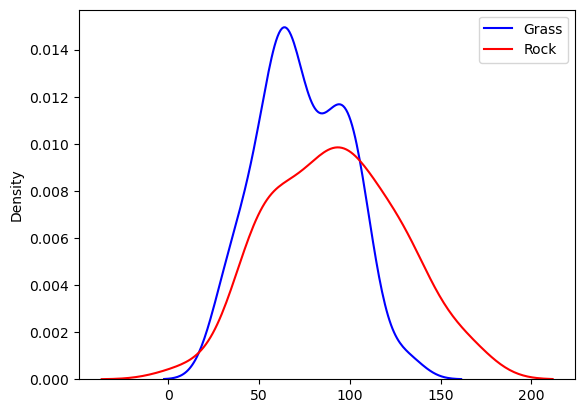

In [438]:
sns.kdeplot(data_grass, color="blue", label="Grass")
sns.kdeplot(data_rock, color="red", label="Rock")
plt.legend()

Вывод: покемоны класса Rock имеют более сильную атаку, чем покемоны Grass

<div class="alert alert-info">
<b>Задание № 2:</b>
    
Профессор Оук уже долго не может спать по ночам, ведь его волнует вопрос, а правда ли, что покемоны в классе `Water` в среднем быстрее, чем покемоны в классе `Normal`.
    
    
Проверьте, прав ли он, и убедите его в своём выводе статистически.
    
Примечание: если есть покемоны, которые относятся к обоим классам, выбросьте их;
    
Вы можете предположить, что распределение скорости движения является нормальным для всех классов покемонов.
</div>

In [299]:
pokemon.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 799 entries, 0 to 798
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   pid        799 non-null    int64 
 1   Name       799 non-null    object
 2   Class 1    799 non-null    object
 3   Class 2    414 non-null    object
 4   HP         799 non-null    int64 
 5   Attack     799 non-null    int64 
 6   Defense    799 non-null    int64 
 7   Sp. Atk    799 non-null    int64 
 8   Sp. Def    799 non-null    int64 
 9   Speed      799 non-null    int64 
 10  Legendary  799 non-null    bool  
dtypes: bool(1), int64(7), object(3)
memory usage: 63.3+ KB


In [304]:
"""Выброс покемонов, которые относятся к двум этим классам одновременно"""
pokemon_new_2 = pokemon.loc[~(((pokemon['Class 1'] == 'Water') | (pokemon['Class 2'] == 'Water')) & ((pokemon['Class 1'] == 'Normal') | (pokemon['Class 2'] == 'Normal')))]

pokemon_new_2.info()


<class 'pandas.core.frame.DataFrame'>
Index: 798 entries, 0 to 798
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   pid        798 non-null    int64 
 1   Name       798 non-null    object
 2   Class 1    798 non-null    object
 3   Class 2    413 non-null    object
 4   HP         798 non-null    int64 
 5   Attack     798 non-null    int64 
 6   Defense    798 non-null    int64 
 7   Sp. Atk    798 non-null    int64 
 8   Sp. Def    798 non-null    int64 
 9   Speed      798 non-null    int64 
 10  Legendary  798 non-null    bool  
dtypes: bool(1), int64(7), object(3)
memory usage: 69.4+ KB


Подсчет показателей для двух групп

In [348]:
pokemon_new_2.loc[(pokemon_new_2['Class 1'] =='Water') | (pokemon_new_2['Class 2'] =='Water')]['Speed'].describe()

count    125.00000
mean      64.93600
std       22.74889
min       15.00000
25%       50.00000
50%       65.00000
75%       81.00000
max      122.00000
Name: Speed, dtype: float64

In [308]:
pokemon_new_2.loc[(pokemon_new_2['Class 1'] =='Normal') | (pokemon_new_2['Class 2'] =='Normal')]['Speed'].describe()

count    101.000000
mean      72.257426
std       28.427330
min        5.000000
25%       50.000000
50%       72.000000
75%       93.000000
max      135.000000
Name: Speed, dtype: float64

Исходя из условия задачи, считаем, что данные распределены нормально

Проверка нулевой гипотезы

Считаем, что разница в скорости между двумя группами - незначительна

In [346]:
data_water = pokemon_new_2.loc[(pokemon_new_2['Class 1'] =='Water') | (pokemon_new_2['Class 2'] =='Water')]['Speed'].values
data_normal = pokemon_new_2.loc[(pokemon_new_2['Class 1'] =='Normal') | (pokemon_new_2['Class 2'] =='Normal')]['Speed'].values

stat, p = st.ttest_ind(data_water, data_normal)

print(f"Статистика = {stat:.5f}, p = {p:.10f}")

if p > 0.05:
    print('Не отклоняем нулевую гипотезу, скорости, вероятно, одинаковые')
else:
    print('Отклоняем нулевую гипотезу, скорости, вероятно, различаются')

Статистика = -2.15091, p = 0.0325535355
Отклоняем нулевую гипотезу, скорости, вероятно, различаются


Продемонстрируем различия графически

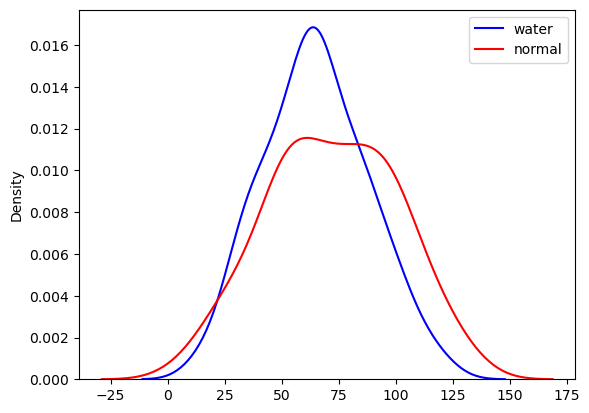

In [316]:
sns.kdeplot(data_water, color="blue", label="water")
sns.kdeplot(data_normal, color="red", label="normal")
plt.legend()

Вывод: покемоны класса Normal в среднем быстрее, чем покемоны класса Water

<div class="alert alert-info">
<b>Задание № 3:</b>
    
Профессор Оук тот еще безумец. Он изобрёл сыворотку, способную ускорить покемона. Однако мы усомнились в эффективности его вакцины. Професоор дал эту сыворотку следующим покемонам: смотри массив `treathed_pokemon`. Проверьте, работает ли вообще его сыворотка, убедите всех в своём выводе статистически.
    
    
Вы можете предположить, что распределение скорости движения является нормальным для всех классов покемонов.

</div>

In [325]:
# Покемоны, которые принимали сыворотку увеличения скорости
treathed_pokemon = ['Mega Beedrill', 'Mega Alakazam',
                    'Deoxys Normal Forme', 'Mega Lopunny']
pokemon.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 799 entries, 0 to 798
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   pid        799 non-null    int64 
 1   Name       799 non-null    object
 2   Class 1    799 non-null    object
 3   Class 2    414 non-null    object
 4   HP         799 non-null    int64 
 5   Attack     799 non-null    int64 
 6   Defense    799 non-null    int64 
 7   Sp. Atk    799 non-null    int64 
 8   Sp. Def    799 non-null    int64 
 9   Speed      799 non-null    int64 
 10  Legendary  799 non-null    bool  
dtypes: bool(1), int64(7), object(3)
memory usage: 63.3+ KB


In [341]:
pokemon_speed_up = pokemon.loc[(pokemon['Name'] == 'Mega Beedrill') 
                            | (pokemon['Name'] == 'Mega Alakazam') 
                            | (pokemon['Name'] == 'Deoxys Normal Forme') 
                            | (pokemon['Name'] == 'Mega Lopunny') ]
pokemon_speed_not = pokemon.loc[~((pokemon['Name'] == 'Mega Beedrill') 
                            | (pokemon['Name'] == 'Mega Alakazam') 
                            | (pokemon['Name'] == 'Deoxys Normal Forme') 
                            | (pokemon['Name'] == 'Mega Lopunny') )]



<class 'pandas.core.frame.DataFrame'>
Index: 795 entries, 0 to 798
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   pid        795 non-null    int64 
 1   Name       795 non-null    object
 2   Class 1    795 non-null    object
 3   Class 2    412 non-null    object
 4   HP         795 non-null    int64 
 5   Attack     795 non-null    int64 
 6   Defense    795 non-null    int64 
 7   Sp. Atk    795 non-null    int64 
 8   Sp. Def    795 non-null    int64 
 9   Speed      795 non-null    int64 
 10  Legendary  795 non-null    bool  
dtypes: bool(1), int64(7), object(3)
memory usage: 69.1+ KB


Подсчет показателей для двух групп

In [342]:
pokemon_speed_up['Speed'].describe()

count      4.000000
mean     145.000000
std        7.071068
min      135.000000
25%      142.500000
50%      147.500000
75%      150.000000
max      150.000000
Name: Speed, dtype: float64

In [343]:
pokemon_speed_not['Speed'].describe()

count    795.000000
mean      67.857862
std       28.616612
min        5.000000
25%       45.000000
50%       65.000000
75%       90.000000
max      180.000000
Name: Speed, dtype: float64

Считаем, что данные распределены нормально

Проверка нулевой гипотезы

Считаем, что разницы в скорости у двух групп нет

In [345]:
data_speed = pokemon_speed_up['Speed'].values
data_not_speed = pokemon_speed_not['Speed'].values

stat, p = st.ttest_ind(data_speed, data_not_speed)

print(f"Статистика = {stat:.5f}, p = {p:.10f}")

if p > 0.05:
    print('Не отклоняем нулевую гипотезу, скорости, вероятно, одинаковые')
else:
    print('Отклоняем нулевую гипотезу, скорости, вероятно, различаются')

Статистика = 5.38744, p = 0.0000000942
Отклоняем нулевую гипотезу, скорости, вероятно, различаются


Продемонстрируем различия графически

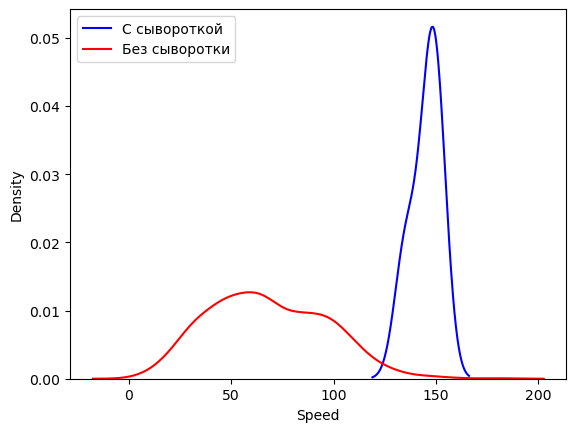

In [347]:
sns.kdeplot(data_speed, color="blue", label="С сывороткой")
sns.kdeplot(data_not_speed, color="red", label="Без сыворотки")
plt.legend()

Вывод: покемоны, которые принимали сыворотку для увеличения скорости, гораздо быстрее (приблизительно в 2,5 раза), чем покемоны, не принимающие сыворотку

<div class="alert alert-info">
<b>Задание № 4:</b>
    
Профессор Оук всегда любил истории про легендарных покемонов. Однако профессор не очень уверен, что они лучше остальных покемонов. Оук предложил разобраться в этом нам. Проверьте, действительно ли сумма характеристик `HP`,`Attack`,`Defense` у легендарных покемонов выше, чем у других покемонов?

А произведение этих же параметров?

Найдите ответы на эти вопросы и убедите всех в своём выводе статистически.
   

Вы можете предположить, что распределение сум и произведений этих параметров является нормальным для всех классов покемонов.

</div>

In [362]:
pokemon_legend = pokemon.loc[(pokemon['Legendary'] == True)]
pokemon_not_legend = pokemon.loc[~(pokemon['Legendary'] == True)]

pokemon['sum_HP_attack_defense'] = pokemon['Attack'] + pokemon['Defense'] + pokemon['HP']
pokemon['mult_HP_attack_defense'] = pokemon['Attack'] * pokemon['Defense'] * pokemon['HP']




,pid,Name,Class 1,Class 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Legendary,sum_HP_attack_defense,mult_HP_attack_defense
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,False,143,108045
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,False,185,234360
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,False,245,544480
3,4,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,False,303,984000
4,5,Charmander,Fire,NaN,39,52,43,60,50,65,False,134,87204


Просмотр основных характеристик

In [361]:
pokemon_legend['sum_HP_attack_defense'].describe()

count     65.000000
mean     309.076923
std       46.429822
min      230.000000
25%      275.000000
50%      305.000000
75%      340.000000
max      440.000000
Name: sum_HP_attack_defense, dtype: float64

In [363]:
pokemon_legend['mult_HP_attack_defense'].describe()

count    6.500000e+01
mean     1.085942e+06
std      5.169911e+05
min      1.800000e+05
25%      6.885000e+05
50%      1.000000e+06
75%      1.350000e+06
max      2.880000e+06
Name: mult_HP_attack_defense, dtype: float64

In [364]:
pokemon_not_legend['sum_HP_attack_defense'].describe()

count    734.000000
mean     214.389646
std       64.400908
min       55.000000
25%      165.000000
50%      212.500000
75%      258.000000
max      440.000000
Name: sum_HP_attack_defense, dtype: float64

In [365]:
pokemon_not_legend['mult_HP_attack_defense'].describe()

count    7.340000e+02
mean     4.250626e+05
std      3.716070e+05
min      2.500000e+03
25%      1.512125e+05
50%      3.311250e+05
75%      5.736438e+05
max      2.460000e+06
Name: mult_HP_attack_defense, dtype: float64

Исходя из основных характеристик данных, можно сказать, что сумма и произведение параметров у легендарных покемонов выше. Продемонстрируем это с помощью статистического теста

Нулевая гипотеза - различий в сумме параметров нет

Считаем, что данные распределены нормально

In [439]:
data_legend_sum = pokemon_legend['sum_HP_attack_defense'].values
data_not_legend_sum = pokemon_not_legend['sum_HP_attack_defense'].values

stat, p = st.ttest_ind(data_legend_sum, data_not_legend_sum)

print(f"Статистика = {stat:.5f}, p = {p:.30f}")

if p > 0.05:
    print('Не отклоняем нулевую гипотезу, суммы параметров, вероятно, одинаковые')
else:
    print('Отклоняем нулевую гипотезу, суммы параметров, вероятно, различаются')

Статистика = 11.58699, p = 0.000000000000000000000000000084
Отклоняем нулевую гипотезу, суммы параметров, вероятно, различаются


Проверим различия между произведениями параметров

Нулевая гипотеза - различий в произведении параметров нет

Считаем, что данные также распределены нормально

In [440]:
data_legend_mult = pokemon_legend['mult_HP_attack_defense'].values
data_not_legend_mult = pokemon_not_legend['mult_HP_attack_defense'].values

stat, p = st.ttest_ind(data_legend_mult, data_not_legend_mult)

print(f"Статистика = {stat:.5f}, p = {p:.45f}")

if p > 0.05:
    print('Не отклоняем нулевую гипотезу, произведения параметров, вероятно, одинаковые')
else:
    print('Отклоняем нулевую гипотезу, произведения параметров, вероятно, различаются')

Статистика = 13.25380, p = 0.000000000000000000000000000000000002230443947
Отклоняем нулевую гипотезу, произведения параметров, вероятно, различаются


Вывод: легендарные покемоны лучше остальных покемонов, так как их средние значение сумм и произведений здоровья, обычной защиты и атаки больше, чем у обычных покемонов

<div class="alert alert-info">
<b>Задание № 5:</b>
    
Профессор Оук частенько наблюдает за боями покемонов. После очередных таких боёв Оук выделил четыре класса `best_defence_class`, которые на его взгляд одинаковы по "силе обычной защиты" `Defense`.

Проверьте, действительно ли эти классы покемонов не отличаются по уровню защиты статистически значимо? Всё та же статистика вам в помощь!
   

Вы можете предположить, что распределение параметров защитных характеристик является нормальным для всех классов покемонов.

</div>

In [ ]:
best_defence_class = ['Rock', 'Ground', 'Steel', 'Ice']
best_defence_class

['Rock', 'Ground', 'Steel', 'Ice']

In [415]:
pokemon_rock = pokemon.loc[((pokemon['Class 1'] == 'Rock') | ((pokemon['Class 2'] == 'Rock'))) 
                           & ((pokemon['Class 2'] != 'Ground') & ((pokemon['Class 1'] != 'Ground')))
                           & ((pokemon['Class 2'] != 'Steel') & ((pokemon['Class 1'] != 'Steel')))
                           & ((pokemon['Class 2'] != 'Ice') & ((pokemon['Class 1'] != 'Ice')))]
pokemon_ground =  pokemon.loc[((pokemon['Class 1'] == 'Ground') | ((pokemon['Class 2'] == 'Ground'))) 
                           & ((pokemon['Class 2'] != 'Rock') & ((pokemon['Class 1'] != 'Rock')))
                           & ((pokemon['Class 2'] != 'Steel') & ((pokemon['Class 1'] != 'Steel')))
                           & ((pokemon['Class 2'] != 'Ice') & ((pokemon['Class 1'] != 'Ice')))]
pokemon_steel = pokemon.loc[((pokemon['Class 1'] == 'Steel') | ((pokemon['Class 2'] == 'Steel'))) 
                           & ((pokemon['Class 2'] != 'Rock') & ((pokemon['Class 1'] != 'Rock')))
                           & ((pokemon['Class 2'] != 'Ground') & ((pokemon['Class 1'] != 'Ground')))
                           & ((pokemon['Class 2'] != 'Ice') & ((pokemon['Class 1'] != 'Ice')))]
pokemon_ice = pokemon.loc[((pokemon['Class 1'] == 'Ice') | ((pokemon['Class 2'] == 'Ice'))) 
                           & ((pokemon['Class 2'] != 'Rock') & ((pokemon['Class 1'] != 'Rock')))
                           & ((pokemon['Class 2'] != 'Ground') & ((pokemon['Class 1'] != 'Ground')))
                           & ((pokemon['Class 2'] != 'Steel') & ((pokemon['Class 1'] != 'Steel')))]
pokemon_ice.head()

,pid,Name,Class 1,Class 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Legendary,sum_HP_attack_defense,mult_HP_attack_defense
93,95,Dewgong,Water,Ice,90,70,80,70,95,70,False,240,504000
97,99,Cloyster,Water,Ice,50,95,180,85,45,70,False,325,855000
132,134,Jynx,Ice,Psychic,65,50,35,115,95,95,False,150,113750
141,143,Lapras,Water,Ice,130,85,80,85,95,60,False,295,884000
155,157,Articuno,Ice,Flying,90,85,100,95,125,85,True,275,765000


Проверим основные характеристики покемонов

In [416]:
pokemon_ice['Defense'].describe()

count     33.000000
mean      78.515152
std       35.804261
min       15.000000
25%       50.000000
50%       80.000000
75%       90.000000
max      184.000000
Name: Defense, dtype: float64

In [417]:
pokemon_ground['Defense'].describe()

count     52.000000
mean      81.076923
std       29.377093
min       25.000000
25%       55.000000
50%       80.000000
75%      105.000000
max      160.000000
Name: Defense, dtype: float64

In [418]:
pokemon_rock['Defense'].describe()

count     41.000000
mean     104.097561
std       38.226826
min       40.000000
25%       85.000000
50%      100.000000
75%      125.000000
max      230.000000
Name: Defense, dtype: float64

In [419]:
pokemon_steel['Defense'].describe()

count     40.000000
mean     109.325000
std       32.157774
min       50.000000
25%       90.250000
50%      100.000000
75%      129.250000
max      230.000000
Name: Defense, dtype: float64

Исходя из основных статистических характеристик данных, можно сказать, что покемоны Steel и Rock не сильно отличаются между собой, а Ice и Ground не сильно отличаются между собой

Проверим это с помощью однофакторного дисперсионного анализа

Считаем, что данные распределены нормально

In [431]:
data_ice = pokemon_ice['Defense'].values
data_steel = pokemon_steel['Defense'].values
data_ground = pokemon_ground['Defense'].values
data_rock = pokemon_rock['Defense'].values
fvalue, pvalue = st.f_oneway(data_ice,data_rock,data_ground,data_steel)
print(f"Статистика = {fvalue:.5f}, p = {pvalue:.5f}")

if pvalue > 0.05:
	print('Не отклоняем нулевую гипотезу, уровни защиты, вероятно, одинаковые')
else:
	print('Отклоняем нулевую гипотезу, уровни защиты, вероятно, различаются')

Статистика = 8.82042, p = 0.00002
Отклоняем нулевую гипотезу, уровни защиты, вероятно, различаются


Посмотрим, какие конкретно покемоны отличаются друг от друга

In [430]:

from statsmodels.stats.multicomp import pairwise_tukeyhsd
defense_values = list(data_ice) + list(data_rock) + list(data_ground) + list(data_steel)
labels = (
    ['Ice'] * len(data_ice) +
    ['Rock'] * len(data_rock) +
    ['Ground'] * len(data_ground) +
    ['Steel'] * len(data_steel)
)

tukey = pairwise_tukeyhsd(endog=defense_values,
groups=labels,
alpha=0.05)

print(tukey)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
Ground    Ice  -2.5618 0.9862 -22.0232 16.8997  False
Ground   Rock  23.0206 0.0071   4.7576 41.2836   True
Ground  Steel  28.2481 0.0006   9.8579 46.6383   True
   Ice   Rock  25.5824 0.0077   5.1325 46.0323   True
   Ice  Steel  30.8098 0.0008  10.2463 51.3734   True
  Rock  Steel   5.2274 0.8976 -14.2058 24.6607  False
-----------------------------------------------------


Вывод: уровень защиты покемонов Ground и Ice не отличается, уровень защиты покемонов Rock и Steel так же не отличается. 

# **Примечание:**

Домашнее задание сдается ссылкой [Google Colab](https://colab.research.google.com/). Мы не сможем проверить его или помочь, если вы пришлете:

*   файлы;
*   архивы;
*   скриншоты кода.

Все обсуждения и консультации по выполнению домашнего задания ведутся только на соответствующем канале в Discord.

**Как правильно задавать вопросы аспирантам, преподавателям и коллегам:**

Прежде чем задать вопрос, попробуйте найти ответ в интернете. Навык самостоятельного поиска информации — один из важнейших. Каждый практикующий специалист любого уровня делает это ежедневно.

Сформулируйте вопрос по алгоритму:

1.   Что я делаю?
2.   Какого результата я ожидаю?
3.   Как фактический результат отличается от ожидаемого?
4.   Что я уже попробовал сделать, чтобы исправить проблему?

По возможности прикрепите к вопросу скриншоты либо ссылки на код. Не выкладывайте все решение, оставляйте только проблемный и воспроизводимый участок кода.